# Sprint A — Step 0 + Chantier 1

**Date :** 2026-05-29  
**Source plan :** [SPRINT_A_PLAN.md](../SPRINT_A_PLAN.md)  
**Objectif :** WAPE 54.05 % → < 40 % (cible North Star précision > 60 %)

## Contenu du notebook

| Étape | Objet |
|---|---|
| **Step 0** | Reconstruction des splits avec codes bruts (`code_client`, `code_article`) à partir de `dataset_step6.parquet` + `dataset_ml_enrichi.parquet` |
| **C1.1** | Lags par couple (1, 7, 30 observations) |
| **C1.2** | Rolling par couple, client, article (mean/std, fenêtres 7/30/90) |
| **C1.3** | Features fréquence récente + prix lag/delta |
| **C1.4** | Cycle annuel (cumul qte année) |
| **C1.5** | Target encoding K-Fold temporel (5 folds expanding window) |
| **C1.6** | Sauvegarde splits v3 (~50 features) |
| **C1.7** | XGBoost Optuna **300 essais** (vs 50 dans notebook 03) |
| **C1.8** | Comparaison MAE v1 (11.87) vs v2 + importance permutation |

> **Prérequis :** `data/processed/{dataset_step6,dataset_ml_enrichi,split_*.parquet}` (générés par notebooks 01 & 02bis).

In [1]:
import warnings, json, time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

DATA = Path('../data/processed')
MODELS = Path('../models')
REPORTS = Path('../reports')
for d in (MODELS, REPORTS):
    d.mkdir(parents=True, exist_ok=True)

print('Workspace prêt.')
print(f'  DATA    : {DATA.resolve()}')
print(f'  MODELS  : {MODELS.resolve()}')
print(f'  REPORTS : {REPORTS.resolve()}')

Workspace prêt.
  DATA    : C:\Users\lenovo\Desktop\Extraction livraison client 2021-2025\data\processed
  MODELS  : C:\Users\lenovo\Desktop\Extraction livraison client 2021-2025\models
  REPORTS : C:\Users\lenovo\Desktop\Extraction livraison client 2021-2025\reports


---
## Step 0 — Reconstruction des splits avec codes bruts

**Constat :** les splits `split_{train,val,test}.parquet` (210 641 / 70 871 / 66 174 = **347 686 lignes**) ne contiennent ni `code_client` ni `code_article` (seulement les encodages de fréquence). Sans ces clés brutes, impossible de calculer les lags / rolling / target encoding par couple.

**Stratégie :**
1. Charger `dataset_step6.parquet` (codes bruts + dates + 41 colonnes) et `dataset_ml_enrichi.parquet` (35 colonnes incluant les features météo / IPI / vacances absentes de step6).
2. Vérifier alignement ligne-à-ligne entre les deux datasets (même longueur 349 390).
3. Concaténer horizontalement → dataset complet avec codes bruts + features enrichies.
4. Filtrer pour ne garder que les 347 686 lignes présentes dans les splits originaux (1 704 lignes filtrées par le pipeline de splitting).
5. Re-splitter temporellement (2021-2023 / 2024 / 2025) → `split_{train,val,test}_v2.parquet`.

In [2]:
s6 = pd.read_parquet(DATA / 'dataset_step6.parquet')
en = pd.read_parquet(DATA / 'dataset_ml_enrichi.parquet')

print(f'step6   : {s6.shape}  (codes bruts + dates)')
print(f'enrichi : {en.shape}  (features meteo / IPI / vacances)')
assert len(s6) == len(en), 'Tailles differentes : alignement impossible'

# Verification de l'alignement ligne-a-ligne sur deux cols communes
chk_qte = (s6['qte_demandee'].reset_index(drop=True) == en['qte_demandee'].reset_index(drop=True)).all()
chk_sta = (s6['statut_enc'].reset_index(drop=True)  == en['statut_enc'].reset_index(drop=True)).all()
print(f'Alignement qte_demandee : {chk_qte} | statut_enc : {chk_sta}')
assert chk_qte and chk_sta, 'Datasets desalignes — abandon'

# Concat horizontal : on garde tout step6 + ce qui est NOUVEAU dans enrichi
new_in_en = [c for c in en.columns if c not in s6.columns]
print(f'\nColonnes ajoutees depuis enrichi ({len(new_in_en)}) :')
print('  ', new_in_en)

s6_full = pd.concat(
    [s6.reset_index(drop=True), en[new_in_en].reset_index(drop=True)],
    axis=1,
)
print(f'\nDataset fusionne : {s6_full.shape}')

step6   : (349390, 41)  (codes bruts + dates)
enrichi : (349390, 35)  (features meteo / IPI / vacances)
Alignement qte_demandee : True | statut_enc : True

Colonnes ajoutees depuis enrichi (11) :
   ['date_cmd', 'date_liv_dem', 'est_jour_ferie_cmd', 'est_jour_ferie_liv_dem', 'pluie_mm_liv_dem', 'vent_max_kmh_liv_dem', 'temp_min_liv_dem', 'ipi_valeur', 'est_vacances_scolaires_liv_dem', 'est_periode_peak_liv_dem', 'est_periode_covid']

Dataset fusionne : (349390, 52)


In [3]:
# Chargement des splits originaux pour identifier les 347 686 lignes "valides"
s_train = pd.read_parquet(DATA / 'split_train.parquet')
s_val   = pd.read_parquet(DATA / 'split_val.parquet')
s_test  = pd.read_parquet(DATA / 'split_test.parquet')

n_target = len(s_train) + len(s_val) + len(s_test)
print(f'Volumetrie cible : train={len(s_train):,} val={len(s_val):,} test={len(s_test):,} -> total {n_target:,}')
print(f'Volumetrie source : {len(s6_full):,} -> delta a exclure : {len(s6_full) - n_target:,}')

# Cle de jointure : suffisamment discriminante pour identifier les lignes filtrees
key_cols = [
    'date_cmd', 'qte_demandee', 'prix', 'statut_enc',
    'code_client_freq', 'code_article_freq',
    'famille_activite_client_enc', 'famille_activite_article_enc',
    'jour_semaine_cmd', 'delai_demande_jours',
]

# Comptage par cle dans l'union des splits (= ensemble a garder)
keep = pd.concat([s_train, s_val, s_test], ignore_index=True)[key_cols]
keep_count = keep.groupby(key_cols, dropna=False).size().rename('n_keep')

# On garde min(n_full, n_keep) occurrences par cle depuis s6_full
s6_full['_rownum'] = s6_full.groupby(key_cols, dropna=False).cumcount()
s6_full = s6_full.merge(keep_count.reset_index(), on=key_cols, how='left')
s6_full['n_keep'] = s6_full['n_keep'].fillna(0).astype(int)
mask_keep = s6_full['_rownum'] < s6_full['n_keep']
s6_kept = s6_full.loc[mask_keep].drop(columns=['_rownum', 'n_keep']).reset_index(drop=True)

print(f'\nApres filtre : {len(s6_kept):,} lignes (cible {n_target:,}) — delta {len(s6_kept) - n_target:+d}')

Volumetrie cible : train=210,641 val=70,871 test=66,174 -> total 347,686
Volumetrie source : 349,390 -> delta a exclure : 1,704

Apres filtre : 347,686 lignes (cible 347,686) — delta +0


In [4]:
# Re-split temporel (mêmes bornes que les splits originaux)
s6_kept['date_cmd'] = pd.to_datetime(s6_kept['date_cmd'])
train_v2 = s6_kept[s6_kept['date_cmd'] <= '2023-12-31'].copy().reset_index(drop=True)
val_v2   = s6_kept[(s6_kept['date_cmd'] >= '2024-01-01') & (s6_kept['date_cmd'] <= '2024-12-31')].copy().reset_index(drop=True)
test_v2  = s6_kept[s6_kept['date_cmd'] >= '2025-01-01'].copy().reset_index(drop=True)

print('=== v2 splits ===')
print(f'  train : {len(train_v2):>8,} (cible {len(s_train):,}, delta {len(train_v2)-len(s_train):+d})')
print(f'  val   : {len(val_v2):>8,} (cible {len(s_val):,},   delta {len(val_v2)-len(s_val):+d})')
print(f'  test  : {len(test_v2):>8,} (cible {len(s_test):,}, delta {len(test_v2)-len(s_test):+d})')
print()
print('Codes bruts presents :', 'code_client' in train_v2.columns, 'code_article' in train_v2.columns)
print('Periodes :')
print(f'  train : {train_v2["date_cmd"].min().date()} -> {train_v2["date_cmd"].max().date()}')
print(f'  val   : {val_v2["date_cmd"].min().date()} -> {val_v2["date_cmd"].max().date()}')
print(f'  test  : {test_v2["date_cmd"].min().date()} -> {test_v2["date_cmd"].max().date()}')

# Sauvegarde
train_v2.to_parquet(DATA / 'split_train_v2.parquet')
val_v2.to_parquet(DATA / 'split_val_v2.parquet')
test_v2.to_parquet(DATA / 'split_test_v2.parquet')
print('\nv2 splits sauvegardes.')

=== v2 splits ===
  train :  210,641 (cible 210,641, delta +0)
  val   :   70,871 (cible 70,871,   delta +0)
  test  :   66,174 (cible 66,174, delta +0)

Codes bruts presents : True True
Periodes :
  train : 2021-01-04 -> 2023-12-31
  val   : 2024-01-01 -> 2024-12-31
  test  : 2025-01-01 -> 2025-12-23

v2 splits sauvegardes.


---
## Chantier 1 — Feature engineering (lags + rolling + target encoding)

### Stratégie anti-leakage

Pour chaque ligne `i` au temps `t`, toutes les features dérivées de la cible (`qte_demandee`) doivent utiliser **uniquement les observations strictement antérieures à t** :

- **Lags** : `groupby(couple).shift(k)` → on prend la valeur k-positions en arrière (≠ t)
- **Rolling** : on calcule sur la série déjà décalée (`shift(1)` puis `.rolling()`) → la fenêtre exclut t
- **Target encoding** :
  - sur **train** : K-Fold expanding window (5 folds trimestriels) → pour chaque fold k, on encode avec la moyenne sur les folds 0…k-1 uniquement
  - sur **val/test** : encodage avec la moyenne sur tout train

Tout le calcul se fait sur le **dataset complet** (train+val+test concaténé) car `shift(1)` est temporellement causal, donc valide même au-delà du split.

In [5]:
# Construction du dataset complet ordonne temporellement par couple
train_v2['split'] = 'train'
val_v2['split']   = 'val'
test_v2['split']  = 'test'
df = pd.concat([train_v2, val_v2, test_v2], ignore_index=True)
df['date_cmd'] = pd.to_datetime(df['date_cmd'])
df = df.sort_values(['code_client', 'code_article', 'date_cmd']).reset_index(drop=True)
print(f'Dataset complet trie : {df.shape}')
print(f'Nombre de couples (client, article) uniques : {df.groupby(["code_client","code_article"]).ngroups:,}')
df.head(3)

Dataset complet trie : (347686, 53)
Nombre de couples (client, article) uniques : 79,536


,num_commande,code_article,date_enregistrement,date_livraison_demandee,code_client,famille_activite_client,famille_activite_article,segment,type_activite,pays,devise,qte_demandee,prix,qte_livree,date_livraison_reelle,statut,taux_satisfaction,livraison_excedentaire,delai_jours,annee_cmd,mois_cmd,trimestre_cmd,semaine_cmd,jour_semaine_cmd,est_fin_mois_cmd,annee_liv_dem,mois_liv_dem,trimestre_liv_dem,jour_semaine_liv_dem,est_weekend_liv_dem,delai_demande_jours,en_retard,statut_enc,devise_enc,pays_enc,famille_activite_client_enc,famille_activite_article_enc,segment_enc,type_activite_enc,code_client_freq,code_article_freq,date_cmd,date_liv_dem,est_jour_ferie_cmd,est_jour_ferie_liv_dem,pluie_mm_liv_dem,vent_max_kmh_liv_dem,temp_min_liv_dem,ipi_valeur,est_vacances_scolaires_liv_dem,est_periode_peak_liv_dem,est_periode_covid,split
0,156406,A0637,2021-10-20,2021-10-26,C00007,CONSTRUCTION,CONSTRUCTION,COUVERTURE,PIECES DETACHEES,FR,EUR,2,15.4900,2.0000,2021-10-26,livre,1.0000,False,0.0000,2021,10,4,42,2,0,2021,10,4,1,0,6,0.0000,1,1,27,1,0,3,9,29,3564,2021-10-20,2021-10-26,0,0,67.0000,50.7000,3.0000,106.6200,1,0,0,train
1,146351,A1042,2021-01-08,2021-01-13,C00007,CONSTRUCTION,CONSTRUCTION,COUVERTURE,ACCESSOIRE,FR,EUR,1,37.0600,1.0000,2021-01-19,livre,1.0000,False,6.0000,2021,1,1,1,4,0,2021,1,1,2,0,5,1.0000,1,1,27,1,0,3,0,29,1966,2021-01-08,2021-01-13,0,0,96.2000,43.7000,-3.1000,100.7000,0,0,1,train
2,154187,A1046,2021-08-23,2021-08-25,C00007,CONSTRUCTION,CONSTRUCTION,COUVERTURE,Outil GAZ,FR,EUR,1,94.4400,1.0000,2021-08-25,livre,1.0000,False,0.0000,2021,8,3,34,0,0,2021,8,3,2,0,2,0.0000,1,1,27,1,0,3,7,29,926,2021-08-23,2021-08-25,0,0,22.3000,31.7000,11.1000,64.3800,1,0,0,train


### C1.1 — Lags par couple (1, 7, 30 observations)

In [6]:
t0 = time.time()
grp = df.groupby(['code_client', 'code_article'], sort=False)['qte_demandee']
df['qte_lag_1']  = grp.shift(1)
df['qte_lag_7']  = grp.shift(7)
df['qte_lag_30'] = grp.shift(30)
print(f'Lags couple calcules en {time.time()-t0:.1f}s')
print(df[['code_client', 'code_article', 'date_cmd', 'qte_demandee',
         'qte_lag_1', 'qte_lag_7', 'qte_lag_30']].head(10))

Lags couple calcules en 0.1s
  code_client code_article   date_cmd  qte_demandee  qte_lag_1  qte_lag_7  \
0      C00007        A0637 2021-10-20             2        NaN        NaN   
1      C00007        A1042 2021-01-08             1        NaN        NaN   
2      C00007        A1046 2021-08-23             1        NaN        NaN   
3      C00007        A1046 2021-10-20             1     1.0000        NaN   
4      C00007        A1065 2021-01-08             2        NaN        NaN   
5      C00007        A1065 2021-10-20             2     2.0000        NaN   
6      C00007        A1191 2021-10-20             2        NaN        NaN   
7      C00007        A1221 2021-02-09             4        NaN        NaN   
8      C00007        A1251 2021-02-09             1        NaN        NaN   
9      C00007        A1258 2021-08-23             1        NaN        NaN   

   qte_lag_30  
0         NaN  
1         NaN  
2         NaN  
3         NaN  
4         NaN  
5         NaN  
6         N

### C1.2 — Rolling par couple, client, article

Fenêtres en nombre d'observations passées (excluant la ligne courante via `shift(1)`).

In [7]:
# Rolling par couple (sur qte deja decalee) — fenetres 7, 30, 90 observations passees
t0 = time.time()
df = df.sort_values(['code_client', 'code_article', 'date_cmd']).reset_index(drop=True)

def roll_after_shift(serie_groupby, window, agg):
    """shift(1) puis rolling -> la fenetre exclut t."""
    shifted = serie_groupby.shift(1)
    rolled = shifted.groupby([df['code_client'], df['code_article']], sort=False).rolling(
        window, min_periods=1 if agg == 'mean' else 2
    )
    return getattr(rolled, agg)().reset_index(level=[0, 1], drop=True)

grp_q = df.groupby(['code_client', 'code_article'], sort=False)['qte_demandee']
df['qte_roll_mean_7']  = roll_after_shift(grp_q, 7,  'mean')
df['qte_roll_mean_30'] = roll_after_shift(grp_q, 30, 'mean')
df['qte_roll_mean_90'] = roll_after_shift(grp_q, 90, 'mean')
df['qte_roll_std_30']  = roll_after_shift(grp_q, 30, 'std')
print(f'Rolling couple : {time.time()-t0:.1f}s')

Rolling couple : 22.1s


In [8]:
# Rolling par client seul (fenetre 30 observations)
t0 = time.time()
df = df.sort_values(['code_client', 'date_cmd']).reset_index(drop=True)
shifted_c = df.groupby('code_client', sort=False)['qte_demandee'].shift(1)
roll_c = shifted_c.groupby(df['code_client'], sort=False).rolling(30, min_periods=1)
df['qte_roll_mean_30_client'] = roll_c.mean().reset_index(level=0, drop=True)
roll_c_std = shifted_c.groupby(df['code_client'], sort=False).rolling(30, min_periods=2)
df['qte_roll_std_30_client']  = roll_c_std.std().reset_index(level=0, drop=True)
print(f'Rolling client : {time.time()-t0:.1f}s')

# Rolling par article seul (fenetre 30 observations)
t0 = time.time()
df = df.sort_values(['code_article', 'date_cmd']).reset_index(drop=True)
shifted_a = df.groupby('code_article', sort=False)['qte_demandee'].shift(1)
roll_a = shifted_a.groupby(df['code_article'], sort=False).rolling(30, min_periods=1)
df['qte_roll_mean_30_article'] = roll_a.mean().reset_index(level=0, drop=True)
roll_a_std = shifted_a.groupby(df['code_article'], sort=False).rolling(30, min_periods=2)
df['qte_roll_std_30_article']  = roll_a_std.std().reset_index(level=0, drop=True)
print(f'Rolling article : {time.time()-t0:.1f}s')

Rolling client : 2.8s
Rolling article : 3.5s


### C1.3 — Features fréquence + prix

In [9]:
# Frequence recente : nb jours depuis derniere cmd, nb cmd 30j sur le couple
t0 = time.time()
df = df.sort_values(['code_client', 'code_article', 'date_cmd']).reset_index(drop=True)
df['nb_jours_depuis_derniere_cmd'] = (
    df.groupby(['code_client', 'code_article'], sort=False)['date_cmd']
      .diff().dt.days
)
df['_dummy'] = 1
shift_d = df.groupby(['code_client', 'code_article'], sort=False)['_dummy'].shift(1)
df['nb_cmd_30j_couple'] = (
    shift_d.groupby([df['code_client'], df['code_article']], sort=False)
           .rolling(30, min_periods=1).sum()
           .reset_index(level=[0, 1], drop=True)
)
df = df.drop(columns=['_dummy'])
print(f'Frequence recente : {time.time()-t0:.1f}s')

# Prix : lag + delta %
t0 = time.time()
df['prix_lag_1']    = df.groupby(['code_client', 'code_article'], sort=False)['prix'].shift(1)
df['prix_delta_pct'] = (df['prix'] - df['prix_lag_1']) / df['prix_lag_1'].replace(0, np.nan)
print(f'Prix features : {time.time()-t0:.1f}s')

Frequence recente : 6.4s
Prix features : 0.1s


### C1.4 — Cycle annuel (cumul qte année)

In [10]:
t0 = time.time()
df['year'] = df['date_cmd'].dt.year
df = df.sort_values(['code_client', 'code_article', 'date_cmd']).reset_index(drop=True)
# cumsum sur la qte deja decalee (exclut t) -> reset annuel par couple
df['_qte_shift'] = (
    df.groupby(['code_client', 'code_article'], sort=False)['qte_demandee']
      .shift(1).fillna(0)
)
df['cumul_qte_annee'] = (
    df.groupby(['code_client', 'code_article', 'year'], sort=False)['_qte_shift']
      .cumsum()
)
df = df.drop(columns=['_qte_shift', 'year'])
print(f'Cycle annuel : {time.time()-t0:.1f}s')

Cycle annuel : 0.9s


### C1.5 — Target encoding K-Fold temporel

- **Train** : 5 folds expanding window (trimestre par trimestre). Pour chaque fold k, on encode avec la **moyenne de `qte_demandee` sur les folds 0…k-1 uniquement**.
- **Val/Test** : encodage avec la moyenne sur **tout train**.
- Trois niveaux d'encodage : couple `(code_client, code_article)`, client seul, article seul.

In [11]:
t0 = time.time()
df['te_couple']  = np.nan
df['te_client']  = np.nan
df['te_article'] = np.nan

# Sous-ensemble train
train_mask = df['split'] == 'train'
train_df = df[train_mask].copy()
train_df['fold_key'] = (
    train_df['date_cmd'].dt.year.astype(str) + 'Q'
    + train_df['date_cmd'].dt.quarter.astype(str)
)
fold_keys = sorted(train_df['fold_key'].unique())
global_mean = float(train_df['qte_demandee'].mean())
print(f'TE : {len(fold_keys)} folds {fold_keys[:3]} ... {fold_keys[-3:]} | global_mean={global_mean:.3f}')

# Calcul par fold expanding
for k in fold_keys:
    past_mask = train_df['fold_key'] < k
    cur_mask  = train_df['fold_key'] == k
    if past_mask.sum() == 0:
        train_df.loc[cur_mask, ['te_couple', 'te_client', 'te_article']] = global_mean
        continue
    past = train_df.loc[past_mask]
    te_couple  = past.groupby(['code_client', 'code_article'])['qte_demandee'].mean()
    te_client  = past.groupby('code_client')['qte_demandee'].mean()
    te_article = past.groupby('code_article')['qte_demandee'].mean()
    cur = train_df.loc[cur_mask]
    train_df.loc[cur_mask, 'te_couple']  = cur.set_index(['code_client', 'code_article']).index.map(te_couple).astype(float)
    train_df.loc[cur_mask, 'te_client']  = cur['code_client'].map(te_client).astype(float)
    train_df.loc[cur_mask, 'te_article'] = cur['code_article'].map(te_article).astype(float)

# Pour val/test : encodage sur TOUT train
full_te_couple  = train_df.groupby(['code_client', 'code_article'])['qte_demandee'].mean()
full_te_client  = train_df.groupby('code_client')['qte_demandee'].mean()
full_te_article = train_df.groupby('code_article')['qte_demandee'].mean()

valtest_mask = df['split'].isin(['val', 'test'])
vt = df.loc[valtest_mask].copy()
vt['te_couple']  = vt.set_index(['code_client', 'code_article']).index.map(full_te_couple).astype(float)
vt['te_client']  = vt['code_client'].map(full_te_client).astype(float)
vt['te_article'] = vt['code_article'].map(full_te_article).astype(float)

# Re-injection des valeurs calculees
df.loc[train_mask,   ['te_couple', 'te_client', 'te_article']] = train_df[['te_couple', 'te_client', 'te_article']].values
df.loc[valtest_mask, ['te_couple', 'te_client', 'te_article']] = vt[['te_couple', 'te_client', 'te_article']].values

# Imputation NaN -> moyenne globale (cas couples inconnus en val/test)
for col in ['te_couple', 'te_client', 'te_article']:
    df[col] = df[col].fillna(global_mean)

print(f'Target encoding K-Fold : {time.time()-t0:.1f}s')
print('\nApercu des TE sur train (premiers folds):')
print(train_df[['fold_key', 'te_couple', 'te_client', 'te_article']].groupby('fold_key').mean().head(8))

TE : 12 folds ['2021Q1', '2021Q2', '2021Q3'] ... ['2023Q2', '2023Q3', '2023Q4'] | global_mean=22.584
Target encoding K-Fold : 4.4s

Apercu des TE sur train (premiers folds):
          te_couple  te_client  te_article
fold_key                                  
2021Q1      22.5843    22.5843     22.5843
2021Q2      28.3690    23.9600     19.2614
2021Q3      27.1870    21.2527     20.5541
2021Q4      28.2680    23.9439     21.9906
2022Q1      26.5138    22.4986     23.3991
2022Q2      24.1422    22.1194     21.3002
2022Q3      25.5395    22.6184     21.5853
2022Q4      31.1784    25.0720     23.8597


### C1.6 — Imputation NaN + sauvegarde splits v3

- **Lags** (`qte_lag_*`) : 0 (premier achat = pas de passé)
- **Rolling** (`qte_roll_*`, `nb_cmd_30j_couple`) : 0
- **`nb_jours_depuis_derniere_cmd`** : -1 (sentinelle premier achat)
- **`prix_lag_1`** : prix courant ; **`prix_delta_pct`** : 0
- **TE** déjà imputées par `global_mean`

In [12]:
lag_cols  = ['qte_lag_1', 'qte_lag_7', 'qte_lag_30']
roll_cols = [
    'qte_roll_mean_7', 'qte_roll_mean_30', 'qte_roll_mean_90', 'qte_roll_std_30',
    'qte_roll_mean_30_client', 'qte_roll_std_30_client',
    'qte_roll_mean_30_article', 'qte_roll_std_30_article',
    'nb_cmd_30j_couple',
]
for c in lag_cols + roll_cols:
    df[c] = df[c].fillna(0)
df['nb_jours_depuis_derniere_cmd'] = df['nb_jours_depuis_derniere_cmd'].fillna(-1)
df['prix_lag_1']     = df['prix_lag_1'].fillna(df['prix'])
df['prix_delta_pct'] = df['prix_delta_pct'].fillna(0)

# Verification : zero NaN sur les nouvelles features
NEW_FEATURES = lag_cols + roll_cols + [
    'nb_jours_depuis_derniere_cmd', 'prix_lag_1', 'prix_delta_pct',
    'cumul_qte_annee', 'te_couple', 'te_client', 'te_article',
]
nan_check = df[NEW_FEATURES].isna().sum()
print('NaN restants par feature (doit etre 0) :')
print(nan_check[nan_check > 0] if nan_check.sum() > 0 else '  Aucun.')
print(f'\nDataset final : {df.shape}')

NaN restants par feature (doit etre 0) :
  Aucun.

Dataset final : (347686, 72)


In [13]:
# Re-split en 3 et sauvegarde
train_v3 = df[df['split'] == 'train'].drop(columns=['split']).reset_index(drop=True)
val_v3   = df[df['split'] == 'val'].drop(columns=['split']).reset_index(drop=True)
test_v3  = df[df['split'] == 'test'].drop(columns=['split']).reset_index(drop=True)

print(f'v3 splits :')
print(f'  train : {len(train_v3):>8,} -> {train_v3.shape[1]} cols')
print(f'  val   : {len(val_v3):>8,} -> {val_v3.shape[1]} cols')
print(f'  test  : {len(test_v3):>8,} -> {test_v3.shape[1]} cols')

train_v3.to_parquet(DATA / 'split_train_v3_features.parquet')
val_v3.to_parquet(DATA / 'split_val_v3_features.parquet')
test_v3.to_parquet(DATA / 'split_test_v3_features.parquet')
print('\nv3 splits sauvegardes.')

v3 splits :
  train :  210,641 -> 71 cols
  val   :   70,871 -> 71 cols
  test  :   66,174 -> 71 cols

v3 splits sauvegardes.


### C1.7 — XGBoost Optuna 300 essais (vs 50 essais notebook 03)

**Espace de recherche élargi vs notebook 03 :**

| Hyperparamètre | Notebook 03 (50 essais) | Notebook 04 (300 essais) |
|---|---|---|
| `n_estimators` | 200-800 | 200-2000 |
| `max_depth` | 4-10 | 3-15 |
| `min_child_weight` | 1-10 | 1-20 |
| `gamma` | — | 0-5 |
| `max_delta_step` | — | 0-10 |
| Pruner | aucun | MedianPruner |
| Tree method | exact | hist |

> **Durée estimée :** 1-3 h sur CPU. Optuna utilise `MedianPruner` pour stopper les essais sous-performants.

In [14]:
# Definition des features v2 = 28 baseline + 19 nouvelles = 47 features
BASE_FEATURES_V1 = [
    'prix', 'delai_demande_jours',
    'code_client_freq', 'code_article_freq',
    'est_jour_ferie_cmd', 'est_jour_ferie_liv_dem',
    'pluie_mm_liv_dem', 'vent_max_kmh_liv_dem', 'temp_min_liv_dem',
    'ipi_valeur',
    'annee_cmd', 'mois_cmd', 'trimestre_cmd', 'semaine_cmd',
    'jour_semaine_cmd', 'est_fin_mois_cmd', 'jour_semaine_liv_dem',
    'statut_enc', 'devise_enc', 'pays_enc',
    'famille_activite_client_enc', 'famille_activite_article_enc',
    'segment_enc', 'type_activite_enc',
    'est_weekend_liv_dem',
    'est_vacances_scolaires_liv_dem', 'est_periode_peak_liv_dem', 'est_periode_covid',
]
FEATURES_V2 = BASE_FEATURES_V1 + NEW_FEATURES
TARGET = 'qte_demandee'

print(f'Features v1 : {len(BASE_FEATURES_V1)}')
print(f'Features nouvelles : {len(NEW_FEATURES)}')
print(f'Features v2 totales : {len(FEATURES_V2)}')

# Verification : toutes les features sont presentes dans les splits v3
missing = [f for f in FEATURES_V2 if f not in train_v3.columns]
assert not missing, f'Features manquantes : {missing}'
print('Toutes les features v2 sont presentes dans les splits.')

Features v1 : 28
Features nouvelles : 19
Features v2 totales : 47
Toutes les features v2 sont presentes dans les splits.


In [15]:
import optuna
from xgboost import XGBRegressor
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_train, y_train = train_v3[FEATURES_V2], train_v3[TARGET]
X_val,   y_val   = val_v3[FEATURES_V2],   val_v3[TARGET]
X_test,  y_test  = test_v3[FEATURES_V2],  test_v3[TARGET]

y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)

inverse = lambda y_log: np.clip(np.expm1(y_log), 0, None)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 2000),
        'max_depth':        trial.suggest_int('max_depth', 3, 15),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'max_delta_step':   trial.suggest_int('max_delta_step', 0, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'objective':        'reg:squarederror',
        'early_stopping_rounds': 50,
        'random_state': 42, 'n_jobs': -1, 'verbosity': 0,
        'tree_method':  'hist',
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)], verbose=False)
    return mean_absolute_error(y_val, inverse(model.predict(X_val)))

N_TRIALS = 300
pruner = optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=5)
study = optuna.create_study(direction='minimize', pruner=pruner)

t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'\nOptuna termine en {(time.time()-t0)/60:.1f} min')
print(f'Best MAE (val) : {study.best_value:.4f}')
print(f'Best params   : {study.best_params}')

  0%|          | 0/300 [00:00<?, ?it/s]


Optuna termine en 583.9 min
Best MAE (val) : 8.4784
Best params   : {'n_estimators': 1108, 'max_depth': 12, 'learning_rate': 0.007727744343980796, 'subsample': 0.8184088069744904, 'colsample_bytree': 0.9583646348411908, 'min_child_weight': 1, 'gamma': 0.004810542114866048, 'max_delta_step': 2, 'reg_alpha': 0.0016761936939109507, 'reg_lambda': 0.0014772820783330119}


In [16]:
import joblib

# Modele final XGBoost v2 : re-entraine sur Train ∪ Val avec les meilleurs hyperparams
best_params = {
    **study.best_params,
    'objective': 'reg:squarederror',
    'random_state': 42, 'n_jobs': -1, 'verbosity': 0,
    'tree_method': 'hist',
}

X_trainval     = pd.concat([X_train, X_val])
y_trainval_log = pd.concat([y_train_log, y_val_log])

xgb_v2 = XGBRegressor(**best_params)
xgb_v2.fit(X_trainval, y_trainval_log)
y_pred_v2 = inverse(xgb_v2.predict(X_test))

def wape(y_true, y_pred):
    return float(np.abs(np.asarray(y_true) - np.asarray(y_pred)).sum() / np.abs(np.asarray(y_true)).sum())

mae_v2  = mean_absolute_error(y_test, y_pred_v2)
rmse_v2 = float(np.sqrt(mean_squared_error(y_test, y_pred_v2)))
r2_v2   = float(r2_score(y_test, y_pred_v2))
wape_v2 = wape(y_test, y_pred_v2)

print('=== XGBoost v2 (Optuna 300 essais, 47 features) — TEST ===')
print(f'MAE  : {mae_v2:.4f}')
print(f'RMSE : {rmse_v2:.4f}')
print(f'R^2  : {r2_v2:.4f}')
print(f'WAPE : {wape_v2:.4%}')

# Sauvegarde modele + hyperparams
joblib.dump(xgb_v2, MODELS / 'xgboost_optuna_v2.pkl')
with open(MODELS / 'xgboost_optuna_v2_params.json', 'w', encoding='utf-8') as f:
    json.dump({
        'best_params':  study.best_params,
        'n_trials':     N_TRIALS,
        'best_val_mae': float(study.best_value),
        'features':     FEATURES_V2,
        'trained_at':   datetime.now().isoformat(timespec='seconds'),
        'test_metrics': {'MAE': mae_v2, 'RMSE': rmse_v2, 'R2': r2_v2, 'WAPE': wape_v2},
    }, f, indent=2, ensure_ascii=False)
print('\nModele + hyperparams sauvegardes.')

=== XGBoost v2 (Optuna 300 essais, 47 features) — TEST ===
MAE  : 8.4221
RMSE : 101.8342
R^2  : 0.6663
WAPE : 38.3424%

Modele + hyperparams sauvegardes.


### C1.8 — Comparaison v1 vs v2 + importance permutation

**Référence v1** (notebook 03, Optuna 50 essais, 28 features) :
- MAE  = 11.87
- RMSE = 132.17
- R²   = 0.4380
- WAPE = 54.05 %

Critère de succès Sprint A : **MAE test < 11.0 (gain > 7 %)**.

In [17]:
# Comparaison v1 (notebook 03) vs v2 (notebook 04)
V1_REF = {'MAE': 11.87, 'RMSE': 132.17, 'R2': 0.4380, 'WAPE': 0.5405}
V2_OBS = {'MAE': mae_v2, 'RMSE': rmse_v2, 'R2': r2_v2, 'WAPE': wape_v2}

comp = pd.DataFrame({
    'v1 (28 feat, Optuna 50)': V1_REF,
    'v2 (47 feat, Optuna 300)': V2_OBS,
})
comp.loc['delta_%'] = (
    (comp['v2 (47 feat, Optuna 300)'] - comp['v1 (28 feat, Optuna 50)'])
    / comp['v1 (28 feat, Optuna 50)'] * 100
)
print('=== Comparaison v1 vs v2 ===')
print(comp.round(4))

target_mae = 11.0
status = 'OK' if mae_v2 < target_mae else 'NON ATTEINT'
print(f'\nCritere succes : MAE test < {target_mae} -> {status} (mae_v2 = {mae_v2:.4f})')

=== Comparaison v1 vs v2 ===
         v1 (28 feat, Optuna 50)  v2 (47 feat, Optuna 300)
MAE                      11.8700                    8.4221
RMSE                    132.1700                  101.8342
R2                        0.4380                    0.6663
WAPE                      0.5405                    0.3834
delta_%                      NaN                       NaN

Critere succes : MAE test < 11.0 -> OK (mae_v2 = 8.4221)


In [18]:
from sklearn.inspection import permutation_importance

# Importance permutation sur sample test 10k (sinon trop long avec 47 features)
sample_idx = np.random.RandomState(42).choice(
    len(X_test), size=min(10000, len(X_test)), replace=False
)
print(f'Calcul de l importance permutation sur {len(sample_idx):,} lignes test...')

t0 = time.time()
perm = permutation_importance(
    xgb_v2,
    X_test.iloc[sample_idx],
    np.log1p(y_test.iloc[sample_idx]),
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)
print(f'Calcule en {(time.time()-t0)/60:.1f} min')

perm_df = (
    pd.DataFrame({
        'feature':         FEATURES_V2,
        'importance_mean': perm.importances_mean,
        'importance_std':  perm.importances_std,
        'is_new':          [f in NEW_FEATURES for f in FEATURES_V2],
    })
    .sort_values('importance_mean', ascending=False)
    .reset_index(drop=True)
)
perm_df.to_csv(REPORTS / 'sprint_a_permutation_importance.csv', index=False)
print('\nTop 15 features (par importance permutation) :')
print(perm_df.head(15).to_string(index=False))

Calcul de l importance permutation sur 10,000 lignes test...
Calcule en 2.5 min

Top 15 features (par importance permutation) :
                 feature  importance_mean  importance_std  is_new
         qte_roll_mean_7           0.2543          0.0053    True
qte_roll_mean_30_article           0.1103          0.0034    True
        qte_roll_mean_30           0.0672          0.0017    True
 qte_roll_mean_30_client           0.0529          0.0005    True
        qte_roll_mean_90           0.0414          0.0013    True
              te_article           0.0223          0.0011    True
               qte_lag_1           0.0164          0.0003    True
                    prix           0.0154          0.0007   False
              prix_lag_1           0.0118          0.0010    True
 qte_roll_std_30_article           0.0108          0.0005    True
  qte_roll_std_30_client           0.0092          0.0003    True
               te_couple           0.0092          0.0011    True
         cumul

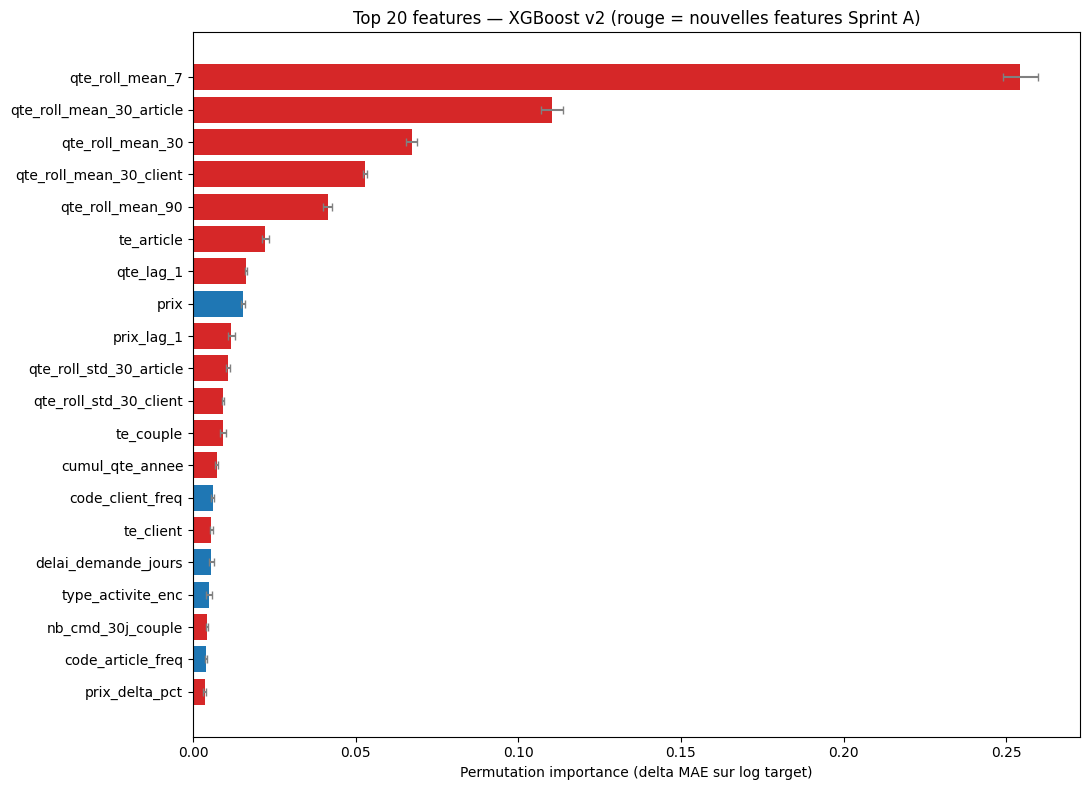


Nouvelles features dans top 10 : 9/10
=> Critere succes C1 (SHAP) : >= 1 nouvelle feature dans top 10 -> OK


In [19]:
# Plot top 20 features avec coloration des nouvelles features
top20 = perm_df.head(20).iloc[::-1]
plt.figure(figsize=(11, 8))
colors = ['#d62728' if is_new else '#1f77b4' for is_new in top20['is_new']]
plt.barh(top20['feature'], top20['importance_mean'],
         xerr=top20['importance_std'], color=colors, ecolor='gray', capsize=3)
plt.xlabel('Permutation importance (delta MAE sur log target)')
plt.title('Top 20 features — XGBoost v2 (rouge = nouvelles features Sprint A)')
plt.tight_layout()
plt.savefig(REPORTS / 'sprint_a_permutation_importance.png', dpi=140)
plt.show()

n_new_in_top10 = perm_df.head(10)['is_new'].sum()
print(f'\nNouvelles features dans top 10 : {n_new_in_top10}/10')
print('=> Critere succes C1 (SHAP) : >= 1 nouvelle feature dans top 10 ->', 'OK' if n_new_in_top10 >= 1 else 'NON')

In [20]:
# Rapport final JSON consolide
metrics_report = {
    'model': 'xgboost_optuna_v2',
    'date': datetime.now().isoformat(timespec='seconds'),
    'n_trials_optuna':   N_TRIALS,
    'n_features':        len(FEATURES_V2),
    'n_features_v1':     len(BASE_FEATURES_V1),
    'n_features_added':  len(NEW_FEATURES),
    'features_added':    NEW_FEATURES,
    'best_params':       study.best_params,
    'best_val_mae':      float(study.best_value),
    'test_metrics_v2':   V2_OBS,
    'test_metrics_v1_ref': V1_REF,
    'delta_pct': {
        k: float((V2_OBS[k] - V1_REF[k]) / V1_REF[k] * 100)
        for k in V1_REF
    },
    'critere_succes_mae_lt_11': bool(mae_v2 < 11.0),
    'new_features_in_top10_importance': int(n_new_in_top10),
    'permutation_top10': perm_df.head(10).to_dict(orient='records'),
}

with open(REPORTS / 'sprint_a_chantier1_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_report, f, indent=2, ensure_ascii=False)
print('Rapport JSON sauvegarde :', REPORTS / 'sprint_a_chantier1_metrics.json')
print('\n=== RECAP SPRINT A — Chantier 1 ===')
print(f'  Test MAE v2  : {mae_v2:.4f} (v1 ref: {V1_REF["MAE"]:.4f}, delta {(mae_v2-V1_REF["MAE"])/V1_REF["MAE"]*100:+.2f}%)')
print(f'  Test WAPE v2 : {wape_v2:.4%} (v1 ref: {V1_REF["WAPE"]:.4%}, delta {(wape_v2-V1_REF["WAPE"])/V1_REF["WAPE"]*100:+.2f}%)')
print(f'  Test R^2 v2  : {r2_v2:.4f} (v1 ref: {V1_REF["R2"]:.4f})')
print(f'  Critere C1 (MAE < 11) : {"OK" if mae_v2 < 11.0 else "NON ATTEINT"}')

Rapport JSON sauvegarde : ..\reports\sprint_a_chantier1_metrics.json

=== RECAP SPRINT A — Chantier 1 ===
  Test MAE v2  : 8.4221 (v1 ref: 11.8700, delta -29.05%)
  Test WAPE v2 : 38.3424% (v1 ref: 54.0500%, delta -29.06%)
  Test R^2 v2  : 0.6663 (v1 ref: 0.4380)
  Critere C1 (MAE < 11) : OK
